# 02. Prediction vs Causal Inference

A prediction model answers a question about **what is likely to happen**. A causal analysis answers a question about **what would happen if we changed something**.

Those two questions often use the same dataset, the same Python packages, and similar-looking regression or machine learning code. They answer different scientific tasks.

This distinction matters in industry because most analytics work eventually feeds a decision: whom to target, what price to set, which model to launch, which customer journey to redesign, whether to deploy an AI assistant, or whether to keep an intervention at all. A model that predicts an outcome accurately may still give the wrong answer about the effect of a proposed action.

In this lecture, we will use a customer-retention example to see why.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish prediction targets from causal estimands.
2. Explain why predictive accuracy does not imply causal validity.
3. Diagnose when a business problem is a prediction problem, a causal problem, or both.
4. Explain why changing an input in a supervised learning model requires a causal design before it can stand in for an intervention simulation.
5. Compare risk targeting with treatment-effect targeting.
6. Understand why causal inference and machine learning are complements rather than substitutes.


## 1. The Core Distinction

A prediction question has the form:

> Given the information currently available, what outcome do we expect?

A causal question has the form:

> If we changed an action, policy, exposure, or treatment, how would the outcome change relative to a comparison action?

Shmueli (2010) emphasizes that explanation and prediction are different modeling goals. Breiman (2001) similarly pushed statisticians to take predictive performance seriously as a distinct goal. Prediction is valuable, and causal inference optimizes a different target.

| Task | Typical question | Target | Evaluation |
|---|---|---|---|
| Description | What happened? | Summary of observed data | Accuracy of measurement and summarization |
| Prediction | What will happen for this unit? | Future or unobserved outcome under the existing data-generating process | Out-of-sample loss, calibration, ranking quality |
| Causal inference | What would happen if we intervened? | Contrast between potential outcomes under different actions | Research design, identification assumptions, estimator behavior, uncertainty |
| Decision analysis | What should we do? | Expected utility, value, cost, risk, or welfare under available actions | Policy value, tradeoffs, robustness, constraints |

A business workflow may need all four. For example, a churn program may describe last month's churn, predict next month's churn, estimate the effect of retention offers, and then decide which customers to target.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

| business_request | prediction_version | causal_version | decision_version |
|---|---|---|---|
| Find customers most likely to churn. | Predict 30-day churn from current customer history. | Estimate the effect of sending a retention offer versus no offer on 30-day churn. | Send offers to customers for whom expected retention value exceeds offer cost. |
| Improve search ranking revenue. | Predict purchase probability for each item-query pair. | Estimate the effect of moving an item higher in the ranking on purchase and margin. | Rank items by expected incremental margin subject to user-experience guardrails. |
| Use an LLM to speed up support. | Predict which tickets are likely to breach SLA. | Estimate the effect of LLM-assisted drafting versus standard tooling on resolution time and reopen rate. | Route only tickets where the assistant improves speed without hurting quality. |


The prediction version and causal version can both be useful, but they answer different questions.

For churn, a risk model tells us who is likely to leave. It does not tell us who will be saved by an offer. The highest-risk customers may be angry about product quality, already committed to a competitor, or ineligible for an economically sensible discount. Lower-risk customers may be highly price-sensitive and easy to retain.

That distinction is central to many applied causal projects:

- risk is about the outcome level;
- treatment effect is about the outcome difference under two actions;
- policy value is about whether the treatment effect is worth the cost.

## 2. A Synthetic Retention Setting

We will simulate a software subscription business. Each customer has pre-treatment characteristics:

- tenure in months;
- weekly product sessions;
- recent support tickets;
- price sensitivity;
- whether they recently saw a competitor offer.

The company sometimes sends a discount offer. The outcome is whether the customer churns in the next 30 days.

The simulation includes hidden potential outcomes, so we can compare observed associations with the true causal effect. In real projects, those potential outcomes are exactly what we do not observe.


**Dataset and experiment setup.** The synthetic dataset represents customers in a subscription business. Each row is one customer, with baseline risk, prior engagement, account value, a retention offer indicator, and a renewal outcome. The treatment is not randomly assigned; high-risk customers are more likely to receive the offer because that is what a real retention team would do. That targeting makes the example realistic for industry work, but it also means a prediction model can learn who is at risk without identifying what the offer caused. The simulation keeps a known treatment effect in the background so we can compare predictive performance with causal interpretation.

In [3]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(7)
n_customers = 30_000

# Latent customer frustration. In real data this might be only partly measured.
service_pain = rng.normal(loc=0, scale=1, size=n_customers)

price_sensitivity = np.clip(
    rng.beta(a=2.2, b=2.5, size=n_customers) + 0.10 * service_pain,
    0,
    1,
)
tenure_months = np.clip(rng.gamma(shape=3.5, scale=8, size=n_customers), 1, 72)
competitor_exposure = rng.binomial(
    n=1,
    p=expit(-0.7 + 0.8 * price_sensitivity + 0.35 * service_pain),
)
weekly_sessions = np.exp(
    1.6
    + 0.018 * tenure_months
    - 0.45 * service_pain
    + rng.normal(loc=0, scale=0.45, size=n_customers)
)
support_tickets = rng.poisson(
    lam=np.exp(-1.15 + 0.95 * service_pain + 0.15 * competitor_exposure)
)

# Baseline churn risk under no offer.
logit_churn_no_offer = (
    -2.1
    - 0.028 * tenure_months
    - 0.30 * np.log1p(weekly_sessions)
    + 0.62 * support_tickets
    + 0.88 * competitor_exposure
    + 0.78 * price_sensitivity
    + 1.05 * service_pain
)

# The discount helps price-sensitive customers, helps slightly when competitors are active,
# and helps less when the real issue is service pain.
discount_logit_shift = (
    1.10 * price_sensitivity
    + 0.22 * competitor_exposure
    - 0.50 * np.maximum(service_pain, 0)
)
logit_churn_offer = logit_churn_no_offer - discount_logit_shift

p_churn_no_offer = expit(logit_churn_no_offer)
p_churn_offer = expit(logit_churn_offer)
true_effect_on_churn_prob = p_churn_offer - p_churn_no_offer

# Historical targeting: the business tends to send offers to customers who already look risky.
offer_propensity = expit(
    -1.2
    + 2.5 * p_churn_no_offer
    + 1.05 * price_sensitivity
    + 0.65 * competitor_exposure
    + 0.35 * support_tickets
)
discount_offer = rng.binomial(n=1, p=offer_propensity)

# Realized potential outcomes and observed outcome.
churn_without_offer = rng.binomial(n=1, p=p_churn_no_offer)
churn_with_offer = rng.binomial(n=1, p=p_churn_offer)
churn_30d = np.where(discount_offer == 1, churn_with_offer, churn_without_offer)

customers = pd.DataFrame(
    {
        "tenure_months": tenure_months,
        "weekly_sessions": weekly_sessions,
        "support_tickets": support_tickets,
        "price_sensitivity": price_sensitivity,
        "competitor_exposure": competitor_exposure,
        "discount_offer": discount_offer,
        "churn_30d": churn_30d,
        # Simulation-only columns. These are not available in real observational data.
        "_p_churn_no_offer": p_churn_no_offer,
        "_p_churn_offer": p_churn_offer,
        "_true_effect_on_churn_prob": true_effect_on_churn_prob,
    }
)

customers.head()


,tenure_months,weekly_sessions,support_tickets,price_sensitivity,competitor_exposure,discount_offer,churn_30d,_p_churn_no_offer,_p_churn_offer,_true_effect_on_churn_prob
0,41.537,7.524,0,0.521,0,1,0,0.029,0.017,-0.013
1,13.297,5.198,1,0.545,1,0,0,0.314,0.190,-0.124
2,12.690,3.331,0,0.574,0,1,0,0.061,0.033,-0.028
3,14.880,14.956,0,0.412,0,1,0,0.019,0.012,-0.007
4,21.207,21.295,1,0.561,1,1,0,0.103,0.047,-0.056


### What Is True in This Simulated World?

Because this is a simulation, we can inspect the true causal effect. The treatment effect is defined on the probability scale as:

$$
P(Y=1 \mid do(\text{offer})) - P(Y=1 \mid do(\text{no offer}))
$$

Here, `Y=1` means churn. So a **negative** effect is good: it means the offer reduces churn probability.


In [4]:
# Build the summary table used to connect the calculation back to the design question.
true_ate = customers["_true_effect_on_churn_prob"].mean()
observed_difference = (
    customers.loc[customers["discount_offer"] == 1, "churn_30d"].mean()
    - customers.loc[customers["discount_offer"] == 0, "churn_30d"].mean()
)

overview = pd.DataFrame(
    {
        "quantity": [
            "Overall offer rate",
            "Overall observed churn rate",
            "True ATE on churn probability: offer minus no offer",
            "Observed churn difference: offered minus not offered",
        ],
        "value": [
            customers["discount_offer"].mean(),
            customers["churn_30d"].mean(),
            true_ate,
            observed_difference,
        ],
    }
)

smart_display(overview)


,quantity,value
0,Overall offer rate,0.518
1,Overall observed churn rate,0.138
2,True ATE on churn probability: offer minus no offer,-0.027
3,Observed churn difference: offered minus not offered,0.110


In What Is True in This Simulated World, the table keeps the counterfactual gap in view. The observed row is only one path for the unit. The causal question compares that path with the one we did not see.

In [5]:
# Assemble the What Is True in This Simulated World? summary table used for interpretation.
group_summary = (
    customers.groupby("discount_offer")
    .agg(
        n=("churn_30d", "size"),
        observed_churn_rate=("churn_30d", "mean"),
        mean_tenure=("tenure_months", "mean"),
        mean_weekly_sessions=("weekly_sessions", "mean"),
        mean_support_tickets=("support_tickets", "mean"),
        mean_price_sensitivity=("price_sensitivity", "mean"),
        competitor_exposure_rate=("competitor_exposure", "mean"),
    )
    .rename(index={0: "No offer", 1: "Discount offer"})
)

smart_display(group_summary)


,n,observed_churn_rate,mean_tenure,mean_weekly_sessions,mean_support_tickets,mean_price_sensitivity,competitor_exposure_rate
discount_offer,,,,,,,
No offer,14466,0.081,28.296,11.631,0.267,0.415,0.299
Discount offer,15534,0.191,27.375,9.161,0.778,0.519,0.543


The true average effect is negative: the discount reduces churn probability on average.

But the observed difference goes in the opposite direction. Customers who received the offer churn more often. The better interpretation is that the historical targeting process sent offers to customers who were already more likely to churn.

This is a classic reason prediction and causality get mixed up in business settings. The treatment variable can be predictive of the outcome because it encodes previous human or algorithmic targeting decisions. A causal reading still needs a design argument.

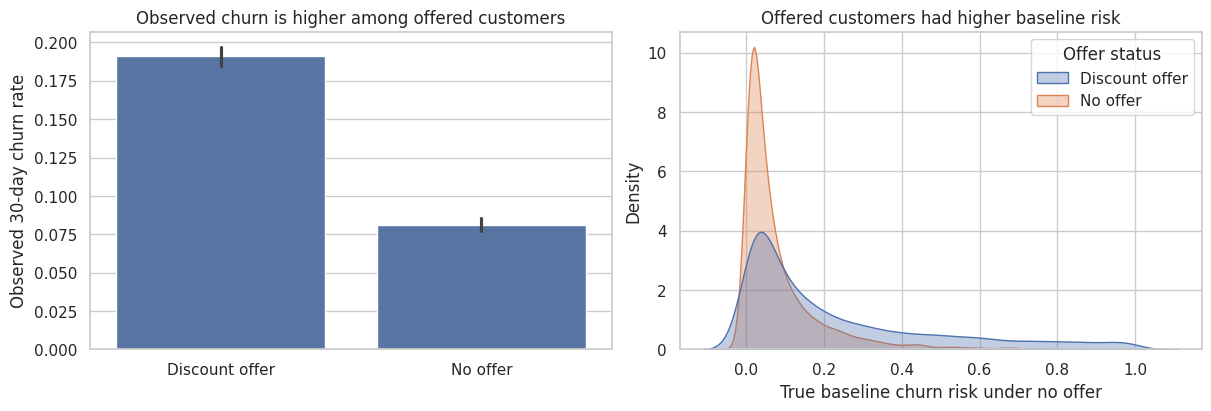

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plot_data = customers.copy()
plot_data["Offer status"] = plot_data["discount_offer"].map({0: "No offer", 1: "Discount offer"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(data=plot_data, x="Offer status", y="churn_30d", errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("Observed churn is higher among offered customers")
axes[0].set_ylabel("Observed 30-day churn rate")
axes[0].set_xlabel("")

sns.kdeplot(
    data=plot_data,
    x="_p_churn_no_offer",
    hue="Offer status",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("Offered customers had higher baseline risk")
axes[1].set_xlabel("True baseline churn risk under no offer")
axes[1].set_ylabel("Density")

plt.show()


The left panel shows the observed association. The right panel shows why that association is misleading: offered customers were selected from a higher-risk part of the population.

The right panel uses a simulation-only quantity, the true baseline churn risk under no offer. In a real project, we would not observe that quantity directly. We would need to reason about the assignment process and use design or modeling assumptions to make the comparison credible.

## 3. A Prediction Model Can Be Useful and Still Not Causal

Now we will train models to predict observed 30-day churn. This is a standard supervised learning task:

$$
\hat{f}(X, A) \approx E[Y \mid X, A]
$$

where `X` is customer history and `A` is whether the customer received the discount offer.

The prediction target is the observed outcome under the historical treatment policy. A new intervention policy asks for a counterfactual outcome, which is a different target.


In [7]:
# Fit the statistical model and collect estimates used in the following interpretation.
features = [
    "tenure_months",
    "weekly_sessions",
    "support_tickets",
    "price_sensitivity",
    "competitor_exposure",
    "discount_offer",
]

target = "churn_30d"

X = customers[features]
y = customers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=10,
    stratify=y,
)

risk_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=80,
    random_state=10,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

risk_pred = risk_model.predict_proba(X_test)[:, 1]

pd.DataFrame(
    {
        "metric": ["ROC AUC", "Average precision", "Mean predicted churn", "Mean observed churn"],
        "value": [
            roc_auc_score(y_test, risk_pred),
            average_precision_score(y_test, risk_pred),
            risk_pred.mean(),
            y_test.mean(),
        ],
    }
)


,metric,value
0,ROC AUC,0.846
1,Average precision,0.577
2,Mean predicted churn,0.137
3,Mean observed churn,0.138


The churn model has strong out-of-sample ranking performance. For a prediction task, that is valuable. The company could use this model to forecast churn volume, prioritize manual review, estimate capacity needs, or trigger non-treatment workflows.

But the metric table does not tell us the effect of the discount offer. ROC AUC evaluates whether customers who churn receive higher scores than customers who do not churn. It does not evaluate whether changing the offer policy would reduce churn.

In [8]:
# Assemble the Discussion summary table used for interpretation.
feature_importance = (
    pd.DataFrame(
        {
            "feature": features,
            "random_forest_importance": risk_model.feature_importances_,
        }
    )
    .sort_values("random_forest_importance", ascending=False)
    .reset_index(drop=True)
)

smart_display(feature_importance)


,feature,random_forest_importance
0,support_tickets,0.504
1,weekly_sessions,0.327
2,price_sensitivity,0.062
3,competitor_exposure,0.059
4,tenure_months,0.029
5,discount_offer,0.019


In A Prediction Model Can Be Useful and Still Not Causal, read the model output through the estimand. The coefficient is useful only after the treatment, comparison, outcome, population, and time horizon are clear.

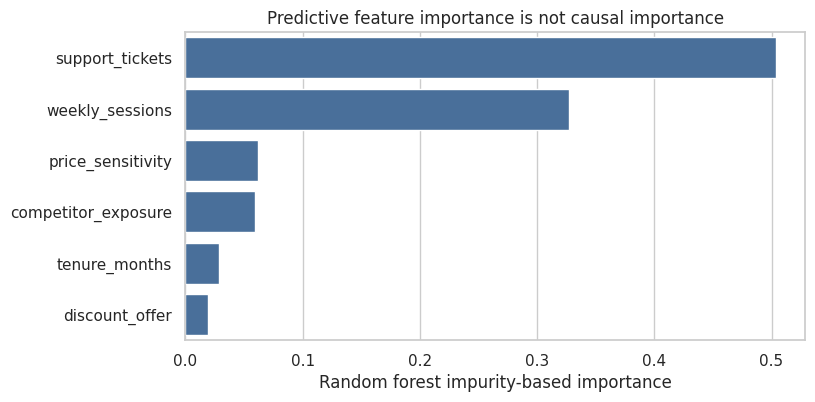

In [9]:
# Build the Discussion plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=feature_importance,
    y="feature",
    x="random_forest_importance",
    color="#3b6ea8",
    ax=ax,
)
ax.set_title("Predictive feature importance is not causal importance")
ax.set_xlabel("Random forest impurity-based importance")
ax.set_ylabel("")
plt.show()


Feature importance describes how the trained prediction model used variables to reduce prediction error. It does not say what would happen if the business intervened on a variable.

Some variables are not even plausible treatments. We cannot assign customers to have a different tenure history. We may be able to change a discount policy, a message, a ranking rule, a product experience, or a support workflow. Causal interpretation requires an intervention, not merely a predictive feature.

This point also matters for explainable AI. A feature can be important for prediction because it is a proxy, a historical targeting artifact, a measurement artifact, or a downstream consequence. That does not make it a lever.

## 4. The Temptation: Flip a Feature and Call It Causal

A common mistake is to take a supervised model and manually change the treatment feature:

1. predict churn with `discount_offer = 0`;
2. predict churn with `discount_offer = 1`;
3. treat the difference as the effect of the discount.

This can be badly wrong because the model was trained to predict observed outcomes under the historical assignment process. It was not trained on randomized treatment variation, and it was not forced to represent the causal structure of the problem.

Let's compare the model-implied change with the true causal effect in the simulation.


In [10]:
# Build the summary table used to connect the calculation back to the design question.
not_offered_test = X_test["discount_offer"].eq(0)
X_no_offer = X_test.loc[not_offered_test].copy()
X_as_offer = X_no_offer.copy()
X_as_offer["discount_offer"] = 1

model_implied_change = (
    risk_model.predict_proba(X_as_offer)[:, 1]
    - risk_model.predict_proba(X_no_offer)[:, 1]
)
true_change_for_same_customers = customers.loc[
    X_no_offer.index,
    "_true_effect_on_churn_prob",
]

pd.DataFrame(
    {
        "quantity": [
            "Prediction-model change from flipping discount_offer 0 to 1",
            "True causal change for the same customers",
        ],
        "mean_change_in_churn_probability": [
            model_implied_change.mean(),
            true_change_for_same_customers.mean(),
        ],
    }
)


,quantity,mean_change_in_churn_probability
0,Prediction-model change from flipping discount_offer 0 to 1,5.990e-04
1,True causal change for the same customers,-1.904e-02


The true causal effect for these customers is negative: offering the discount would reduce churn probability.

The prediction-model flip is close to zero in this run. In other datasets it could easily have the wrong sign. The exact number matters less than the lesson that a supervised model has learned patterns useful for predicting observed churn, not a guaranteed response surface under interventions.

Changing a feature in a predictive model is valid only under additional assumptions. For example, it might be reasonable if the treatment was randomized, if all confounding was properly handled, if the feature change corresponds to a well-defined intervention, and if the model estimates the right conditional causal quantity. Those are causal assumptions, not prediction metrics.

## 5. A Simple Association Model Can Be Even More Misleading

The previous random forest had many customer features. What if someone builds an extremely simple model using only whether the customer received a discount offer?

This is not a good predictive model, but it is a useful diagnostic because it mirrors a common dashboard interpretation: "offered customers churn more, so offers are bad."


In [11]:
# Fit the statistical model and collect estimates used in the following interpretation.
simple_X = customers[["discount_offer"]]
simple_y = customers["churn_30d"]

simple_X_train, simple_X_test, simple_y_train, simple_y_test = train_test_split(
    simple_X,
    simple_y,
    test_size=0.30,
    random_state=10,
    stratify=simple_y,
)

simple_model = LogisticRegression(max_iter=1000)
simple_model.fit(simple_X_train, simple_y_train)
simple_pred = simple_model.predict_proba(simple_X_test)[:, 1]

simple_results = pd.DataFrame(
    {
        "quantity": [
            "Simple model ROC AUC",
            "Coefficient on discount_offer",
            "Observed difference: offered minus not offered",
            "True ATE: offer minus no offer",
        ],
        "value": [
            roc_auc_score(simple_y_test, simple_pred),
            simple_model.coef_[0][0],
            observed_difference,
            true_ate,
        ],
    }
)

smart_display(simple_results)


,quantity,value
0,Simple model ROC AUC,0.618
1,Coefficient on discount_offer,0.968
2,Observed difference: offered minus not offered,0.110
3,True ATE: offer minus no offer,-0.027


The simple model says the offer is positively associated with churn. That association is real in the observed data, but it is not the causal effect.

The coefficient is positive because offer assignment is a risk marker. The historical policy sent more offers to customers who were already likely to churn. This is why causal inference begins by asking how treatment was assigned.

A predictive model is allowed to use treatment assignment as a marker of risk. A causal analysis must ask whether the treatment and comparison groups are comparable for the intervention question.

## 6. Risk Targeting Differs from Effect Targeting

Prediction models often rank customers by outcome risk. That can be useful, but targeting the highest-risk customers is not always the best intervention policy.

Suppose the company can afford to send discounts to 20% of customers. Compare five policies:

1. send no offers;
2. send offers to a random 20%;
3. send offers to the highest-risk 20%;
4. send offers to the 20% with the largest true treatment benefit;
5. send offers to everyone.

In real life, policy 4 is not directly available because true treatment effects are unknown. We include it as an oracle benchmark to clarify the concept.


In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
budget_fraction = 0.20
budget = int(budget_fraction * len(customers))

baseline_risk = customers["_p_churn_no_offer"].to_numpy()
true_benefit = (
    customers["_p_churn_no_offer"]
    - customers["_p_churn_offer"]
).to_numpy()

risk_targeting_policy = np.zeros(len(customers), dtype=int)
risk_targeting_policy[np.argsort(baseline_risk)[-budget:]] = 1

effect_targeting_policy = np.zeros(len(customers), dtype=int)
effect_targeting_policy[np.argsort(true_benefit)[-budget:]] = 1

random_policy = np.zeros(len(customers), dtype=int)
random_policy[rng.choice(len(customers), size=budget, replace=False)] = 1

no_offer_policy = np.zeros(len(customers), dtype=int)
everyone_policy = np.ones(len(customers), dtype=int)


def expected_churn_under_policy(policy):
    """
    Estimate expected churn after applying a targeting policy to the customer data.
    
    Idea:
        This compares decision rules by averaging the churn risk that remains after the rule decides who receives retention action.
    
    Args:
        policy: Callable policy rule that returns whether each unit should receive the intervention.
    
    Returns:
        float: Mean predicted churn rate under the proposed policy.
    """
    return np.where(
        policy == 1,
        customers["_p_churn_offer"],
        customers["_p_churn_no_offer"],
    ).mean()

baseline_churn_if_no_offers = expected_churn_under_policy(no_offer_policy)

policy_results = pd.DataFrame(
    [
        ("No offers", no_offer_policy),
        ("Random 20%", random_policy),
        ("Highest-risk 20%", risk_targeting_policy),
        ("Largest-benefit 20% oracle", effect_targeting_policy),
        ("Offer everyone", everyone_policy),
    ],
    columns=["policy", "assignment"],
)
policy_results["offer_rate"] = policy_results["assignment"].map(np.mean)
policy_results["expected_churn_rate"] = policy_results["assignment"].map(expected_churn_under_policy)
policy_results["churn_reduction_vs_no_offers"] = (
    baseline_churn_if_no_offers - policy_results["expected_churn_rate"]
)
policy_results = policy_results.drop(columns="assignment")

smart_display(policy_results)

,policy,offer_rate,expected_churn_rate,churn_reduction_vs_no_offers
0,No offers,0.0,0.158,0.000
1,Random 20%,0.2,0.153,0.005
2,Highest-risk 20%,0.2,0.148,0.010
3,Largest-benefit 20% oracle,0.2,0.140,0.018
4,Offer everyone,1.0,0.131,0.027


In Risk Targeting Differs from Effect Targeting, the table keeps the counterfactual gap in view. This is the missing-outcome problem in miniature: one observed result, two potential worlds.

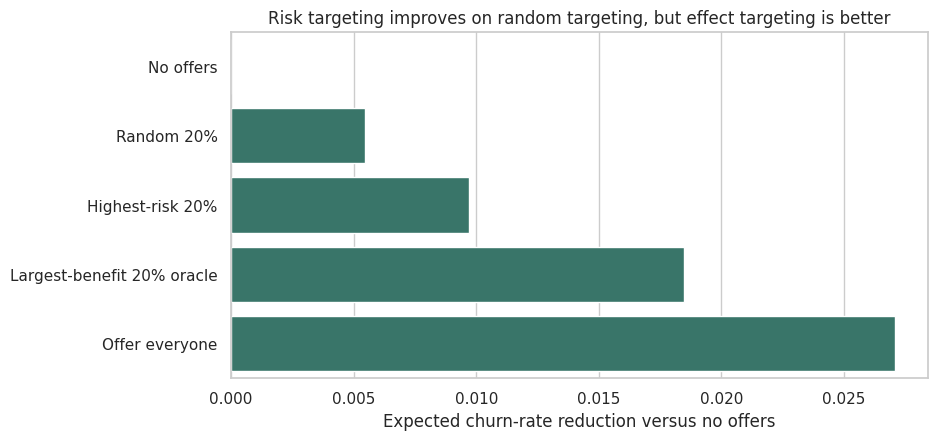

In [13]:
# Build the Risk Targeting Is Not the Same as Effect Targeting plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = policy_results.sort_values("churn_reduction_vs_no_offers", ascending=True)
sns.barplot(
    data=ordered,
    x="churn_reduction_vs_no_offers",
    y="policy",
    color="#2f7f6f",
    ax=ax,
)
ax.set_title("Risk targeting improves on random targeting, but effect targeting is better")
ax.set_xlabel("Expected churn-rate reduction versus no offers")
ax.set_ylabel("")
plt.show()


The highest-risk customers are not necessarily the customers with the largest treatment effects. Risk targeting beats random targeting in this simulation because high-risk customers have more churn to prevent. But the oracle effect-targeting policy does better because it targets customers whose churn probability changes most under the offer.

This is the core idea behind uplift modeling, heterogeneous treatment effect estimation, and policy learning:

- prediction asks who is likely to churn;
- causal effect estimation asks whose churn probability changes if treated;
- policy learning asks whom to treat after considering costs, constraints, and guardrails.

In an industry setting, the difference can be large. A retention team does not merely want to find likely churners. It wants to find customers whose behavior is movable by the available intervention.

## 7. When Is a Problem Mostly Predictive?

Kleinberg, Ludwig, Mullainathan, and Obermeyer (2015) use the phrase **prediction policy problems** for policy decisions where the central uncertainty is predictive rather than causal.

Examples:

- A doctor knows that a treatment should be given if a patient has a disease; the hard part is predicting whether the patient has it.
- A lender knows the action conditional on default risk; the hard part is predicting default risk.
- A platform knows a safety review is needed for high-risk content; the hard part is predicting risk.

In these settings, causal inference may not be the main bottleneck. Prediction can directly improve the decision if the mapping from prediction to action is already justified.

But many industry problems are not purely predictive. They involve an intervention whose effect is uncertain:

- Should we send this discount?
- Should we change this ranking?
- Should we deploy this AI workflow?
- Should we contact this seller?
- Should we raise this price?

Those are causal questions because the action itself changes the outcome-generating process.


| scenario | main_task | why |
|---|---|---|
| Predict fraud risk to decide which transactions receive manual review | Prediction-heavy | The review action is costly, but the immediate need is ranking latent risk. |
| Estimate whether manual review deters future seller fraud | Causal-heavy | The question is whether the review intervention changes later behavior. |
| Predict which tickets will breach SLA | Prediction-heavy | The model forecasts risk under current operations. |
| Estimate whether LLM-assisted drafting reduces resolution time without increasing reopen rate | Causal-heavy | The question compares outcomes under two workflows. |
| Target retention offers to maximize incremental profit | Both | We need risk, treatment effects, costs, and a targeting policy. |


## 8. Practical Rules for Data Scientists

Use these rules before interpreting a model.

1. **If the question says "will happen," think prediction.** Use train/test splits, calibration, ranking metrics, and monitoring.
2. **If the question says "what if we do," think causal inference.** Define treatment, comparison, outcome, population, time horizon, and estimand.
3. **If the action changes the future data-generating process, prediction alone is not enough.** You need assumptions about intervention effects.
4. **Do not treat feature importance as causal importance.** Feature importance explains model behavior, not real-world intervention effects.
5. **Do not treat model feature-flipping as causal simulation unless the design justifies it.** Changing `A` inside a trained model differs from $do(A=a)$.
6. **Separate risk from response.** High outcome risk does not imply high treatment benefit.
7. **Ask how treatment was assigned.** Treatment assignment often carries information about risk, eligibility, human judgment, and past policy.
8. **Use machine learning inside causal workflows carefully.** ML is extremely useful for nuisance functions, heterogeneous effects, and policy learning, but the estimand and identification strategy still matter.

Athey and Imbens (2017) describe randomized experiments as the gold standard for policy effects while also emphasizing the importance of modern methods when experiments are difficult. Mullainathan and Spiess (2017) discuss how machine learning can be valuable in applied econometrics, especially for prediction tasks and high-dimensional settings. The synthesis is not "ML or causal inference." It is: use each tool for the question it is designed to answer.


## 9. Key Takeaways

1. Prediction estimates outcomes under the observed data-generating process; causal inference estimates contrasts under interventions.
2. A model can have excellent out-of-sample accuracy and still fail to answer an intervention question.
3. Historical treatment assignment can be predictive because it encodes prior targeting decisions. That prediction is separate from the treatment's causal effect.
4. Feature importance is not causal importance.
5. Flipping a treatment feature inside a supervised model requires a causal design before it can be used as a counterfactual.
6. Targeting high-risk units differs from targeting high-benefit units.
7. Industry decision systems often need both prediction and causal inference: prediction for risk, causal inference for response, and decision analysis for value.

## Preview of the Next Lecture

The next lecture introduces potential outcomes and counterfactuals. We will formalize the idea that each unit has multiple possible outcomes, but we observe only the outcome corresponding to the action actually taken.


## References

- Athey, S., & Imbens, G. W. (2017). The state of applied econometrics: Causality and policy evaluation. *Journal of Economic Perspectives, 31*(2), 3-32. [https://doi.org/10.1257/jep.31.2.3](https://doi.org/10.1257/jep.31.2.3). Access: open / DOI page.
- Breiman, L. (2001). Statistical modeling: The two cultures (with comments and a rejoinder by the author). *Statistical Science, 16*(3), 199-231. [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726). Access: open / DOI page.
- Kleinberg, J., Ludwig, J., Mullainathan, S., & Obermeyer, Z. (2015). Prediction policy problems. *American Economic Review, 105*(5), 491-495. [https://doi.org/10.1257/aer.p20151023](https://doi.org/10.1257/aer.p20151023). Access: open / DOI page.
- Mullainathan, S., & Spiess, J. (2017). Machine learning: An applied econometric approach. *Journal of Economic Perspectives, 31*(2), 87-106. [https://doi.org/10.1257/jep.31.2.87](https://doi.org/10.1257/jep.31.2.87). Access: open / DOI page.
- Shmueli, G. (2010). To explain or to predict? *Statistical Science, 25*(3), 289-310. [https://doi.org/10.1214/10-STS330](https://doi.org/10.1214/10-STS330). Access: open / DOI page.
